In [2]:
# pip install torch pyro-ppl sbi matplotlib

import torch
import pyro
import pyro.distributions as dist
import matplotlib.pyplot as plt

from pyro.infer import MCMC, NUTS

from sbi.inference import NPE_C, SMCABC
from sbi.utils import BoxUniform


# ============================================================
# 1. SETTINGS
# ============================================================

torch.manual_seed(123)
pyro.set_rng_seed(123)

# Keep this deliberately small because ABC uses the full y.
J = 3       # groups
N = 8       # observations per group
D_Y = J * N

NPE_NUM_SIMS = 20_000
ABC_NUM_SIMS = 20_000
POST_SAMPLES = 2_000

# Same covariate values in every group.
x = torch.linspace(-1.0, 1.0, N)

# theta =
# [mu_alpha, beta, sigma_alpha, sigma_y]

parameter_names = [
    "mu_alpha",
    "beta",
    "sigma_alpha",
    "sigma_y",
]

theta_true = torch.tensor([
    0.5,    # population intercept
    1.2,    # common slope
    0.6,    # between-group SD
    0.4,    # observation SD
])


# ============================================================
# 2. COMMON PRIOR
# ============================================================
#
# Uniform priors are not necessarily what I would use in a
# real analysis, but they make it extremely easy to guarantee
# identical priors in Pyro and sbi.
# ============================================================

low = torch.tensor([
    -3.0,   # mu_alpha
    -3.0,   # beta
     0.05,  # sigma_alpha
     0.05,  # sigma_y
])

high = torch.tensor([
    3.0,
    3.0,
    2.0,
    2.0,
])

prior = BoxUniform(
    low=low,
    high=high,
)


# ============================================================
# 3. COMMON SIMULATOR
# ============================================================
#
# Model:
#
# z_j ~ Normal(0, 1)
#
# alpha_j = mu_alpha + sigma_alpha * z_j
#
# y_ij ~ Normal(
#     alpha_j + beta * x_ij,
#     sigma_y
# )
#
# The group effects are latent nuisance variables.
#
# SBI and ABC infer the four population parameters:
#
# theta = (mu_alpha, beta, sigma_alpha, sigma_y)
#
# while integrating over the latent alpha_j through simulation.
# ============================================================

def simulator(theta):

    theta = torch.as_tensor(
        theta,
        dtype=torch.float32,
    )

    # sbi may give either one theta or a batch.
    single = theta.ndim == 1

    if single:
        theta = theta.unsqueeze(0)

    batch_size = theta.shape[0]

    mu_alpha = theta[:, 0]
    beta = theta[:, 1]
    sigma_alpha = theta[:, 2]
    sigma_y = theta[:, 3]

    # Non-centred random intercepts.
    z = torch.randn(
        batch_size,
        J,
    )

    alpha = (
        mu_alpha[:, None]
        + sigma_alpha[:, None] * z
    )

    # Shape:
    # [batch, J, N]

    mean = (
        alpha[:, :, None]
        + beta[:, None, None]
        * x[None, None, :]
    )

    y = (
        mean
        + sigma_y[:, None, None]
        * torch.randn_like(mean)
    )

    # Give SBI / ABC the FULL data, not summary statistics.
    y = y.reshape(
        batch_size,
        J * N,
    )

    if single:
        return y.squeeze(0)

    return y


# ============================================================
# 4. GENERATE OBSERVED DATA
# ============================================================

y_obs = simulator(theta_true)

print("Observed y shape:", y_obs.shape)
print("True parameters:")

for name, value in zip(
    parameter_names,
    theta_true,
):
    print(
        f"{name:12s} = {value:.3f}"
    )

Observed y shape: torch.Size([24])
True parameters:
mu_alpha     = 0.500
beta         = 1.200
sigma_alpha  = 0.600
sigma_y      = 0.400


In [3]:
# ============================================================
# 5. FULL BAYESIAN MODEL: PYRO + NUTS
# ============================================================
#
# Same hierarchical generative model as simulator().
#
# Here Pyro can explicitly evaluate:
#
# p(y | theta, z)
#
# and therefore use NUTS.
# ============================================================

def pyro_model(y_flat):

    y = y_flat.reshape(J, N)

    mu_alpha = pyro.sample(
        "mu_alpha",
        dist.Uniform(-3.0, 3.0),
    )

    beta = pyro.sample(
        "beta",
        dist.Uniform(-3.0, 3.0),
    )

    sigma_alpha = pyro.sample(
        "sigma_alpha",
        dist.Uniform(0.05, 2.0),
    )

    sigma_y = pyro.sample(
        "sigma_y",
        dist.Uniform(0.05, 2.0),
    )

    # Non-centred parameterisation.
    z = pyro.sample(
        "z",
        dist.Normal(
            torch.zeros(J),
            torch.ones(J),
        ).to_event(1),
    )

    alpha = (
        mu_alpha
        + sigma_alpha * z
    )

    mean = (
        alpha[:, None]
        + beta * x[None, :]
    )

    pyro.sample(
        "y",
        dist.Normal(
            mean,
            sigma_y,
        ).to_event(2),
        obs=y,
    )


print("\nRunning Pyro NUTS...")

nuts_kernel = NUTS(
    pyro_model,
    target_accept_prob=0.9,
)

mcmc = MCMC(
    nuts_kernel,
    warmup_steps=1_000,
    num_samples=POST_SAMPLES,
    num_chains=1,
)

mcmc.run(y_obs)

pyro_samples_raw = mcmc.get_samples()

nuts_samples = torch.stack(
    [
        pyro_samples_raw["mu_alpha"],
        pyro_samples_raw["beta"],
        pyro_samples_raw["sigma_alpha"],
        pyro_samples_raw["sigma_y"],
    ],
    dim=1,
)


Running Pyro NUTS...


Sample: 100%|████████████████████████████████████████| 3000/3000 [02:20, 21.38it/s, step size=1.52e-01, acc. prob=0.920]                                               


In [4]:
# ============================================================
# 6. NEURAL SBI: NPE
# ============================================================
#
# Draw theta from same prior.
# Generate full y from same simulator.
#
# NPE learns:
#
#     q_phi(theta | y)
#
# ============================================================

print("\nGenerating NPE simulations...")

theta_npe = prior.sample(
    (NPE_NUM_SIMS,)
)

y_npe = simulator(theta_npe)

print("theta:", theta_npe.shape)
print("y:", y_npe.shape)


print("\nTraining NPE...")

inference = NPE_C(
    prior=prior,
)

density_estimator = (
    inference
    .append_simulations(
        theta_npe,
        y_npe,
    )
    .train()
)

posterior = inference.build_posterior(
    density_estimator
)

posterior.set_default_x(
    y_obs
)

npe_samples = posterior.sample(
    (POST_SAMPLES,)
)


Generating NPE simulations...
theta: torch.Size([20000, 4])
y: torch.Size([20000, 24])

Training NPE...
 Neural network successfully converged after 109 epochs.

  0%|          | 0/2000 [00:00<?, ?it/s]

In [7]:
# ============================================================
# 7. ABC-SMC
# ============================================================
#
# Again:
#
# same prior
# same simulator
# full y
#
# No summary statistics.
#
# We use mean squared error:
#
# d(y_sim, y_obs)
#
# as the ABC discrepancy.
# ============================================================

print("\nRunning ABC-SMC...")

abc = SMCABC(
    simulator=simulator,
    prior=prior,

    # Full-y discrepancy
    distance="mse",

    # Beaumont et al. style SMC-ABC
    algorithm_variant="C",

    # simulator handles batches
    simulation_batch_size=256,

    show_progress_bars=True,
)

abc_particles, abc_info = abc(
    x_o=y_obs.unsqueeze(0),

    # particles retained in each SMC population
    num_particles=500,

    # simulations used to initialise population
    num_initial_pop=5_000,

    # total simulation budget
    num_simulations=ABC_NUM_SIMS,

    # progressively reduce epsilon
    epsilon_decay=0.8,

    # adapt epsilon to distance distribution
    distance_based_decay=True,

    # return SMC weights etc.
    return_summary=True,
)


# ============================================================
# 8. RESAMPLE ABC PARTICLES USING THEIR SMC WEIGHTS
# ============================================================
#
# ABC-SMC particles are weighted.
#
# For plotting/comparison, resample them according to the
# final population weights.
# ============================================================

last_log_weights = abc_info[
    "weights"
][-1]

last_weights = (
    last_log_weights
    .exp()
)

abc_samples = (
    SMCABC
    .sample_from_population_with_weights(
        particles=abc_particles,
        weights=last_weights,
        num_samples=POST_SAMPLES,
    )
)


print("\nABC epsilon sequence:")

for i, eps in enumerate(
    abc_info["epsilons"]
):
    print(
        f"population {i}: "
        f"epsilon = {float(eps):.4f}"
    )


Running ABC-SMC...


Running 5000 simulations.:   0%|          | 0/5000 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Running 314 simulations.:   0%|          | 0/314 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

...

Running 281 simulations.:   0%|          | 0/281 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Running 374 simulations.:   0%|          | 0/374 [00:00<?, ?it/s]

Running 295 simulations.:   0%|          | 0/295 [00:00<?, ?it/s]


ABC epsilon sequence:
population 0: epsilon = 2.3344
population 1: epsilon = 2.1828
population 2: epsilon = 2.0050
population 3: epsilon = 1.8267
population 4: epsilon = 1.6588
population 5: epsilon = 1.4795
population 6: epsilon = 1.3439
population 7: epsilon = 1.2390
population 8: epsilon = 1.1480
population 9: epsilon = 1.0538




POSTERIOR COMPARISON

mu_alpha (true = 0.500)
NUTS     mean =   0.397  median =   0.390  95% CI = ( -0.025,   1.015)
NPE      mean =   0.482  median =   0.503  95% CI = ( -0.647,   1.596)
ABC-SMC  mean =   0.345  median =   0.340  95% CI = ( -0.734,   1.555)

beta (true = 1.200)
NUTS     mean =   1.087  median =   1.089  95% CI = (  0.878,   1.287)
NPE      mean =   1.117  median =   1.115  95% CI = (  0.859,   1.400)
ABC-SMC  mean =   1.123  median =   1.122  95% CI = (  0.017,   2.183)

sigma_alpha (true = 0.600)
NUTS     mean =   0.300  median =   0.176  95% CI = (  0.056,   1.358)
NPE      mean =   0.744  median =   0.707  95% CI = (  0.099,   1.620)
ABC-SMC  mean =   0.660  median =   0.522  95% CI = (  0.078,   1.799)

sigma_y (true = 0.400)
NUTS     mean =   0.334  median =   0.324  95% CI = (  0.245,   0.470)
NPE      mean =   0.338  median =   0.334  95% CI = (  0.116,   0.584)
ABC-SMC  mean =   0.393  median =   0.346  95% CI = (  0.055,   0.940)


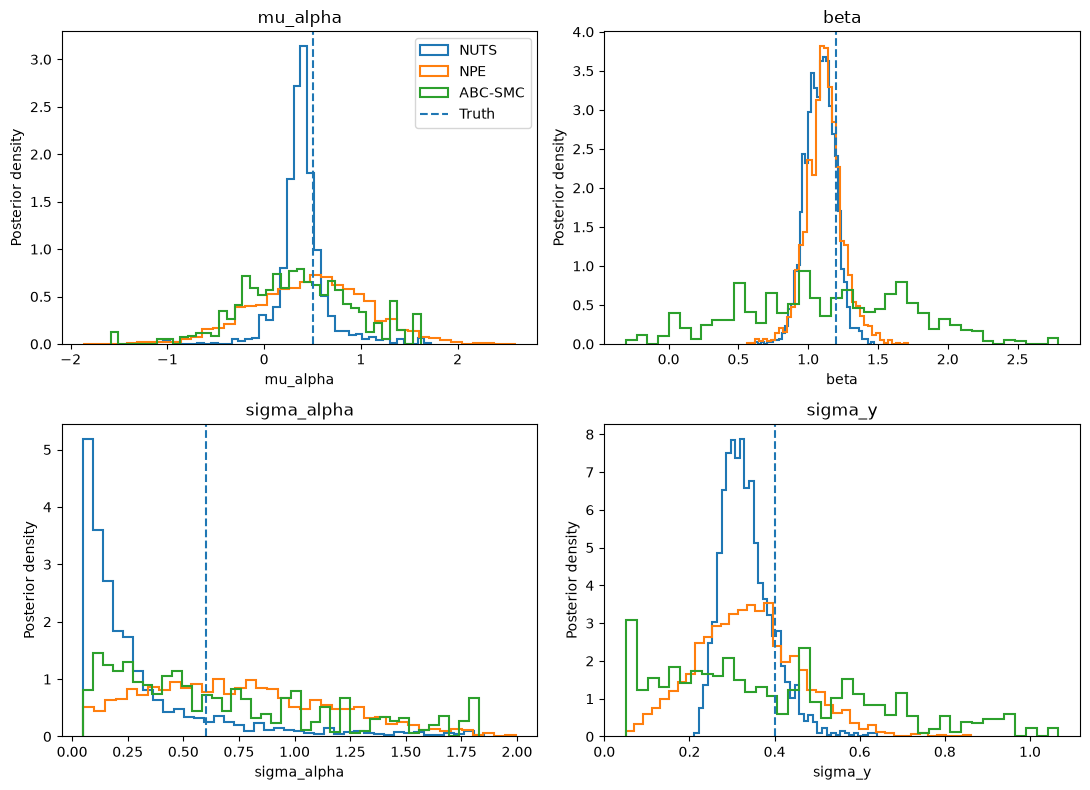

In [8]:
# ============================================================
# 9. POSTERIOR SUMMARIES
# ============================================================

methods = {
    "NUTS": nuts_samples,
    "NPE": npe_samples,
    "ABC-SMC": abc_samples,
}


def summarise(samples):

    mean = samples.mean(dim=0)

    lower = torch.quantile(
        samples,
        0.025,
        dim=0,
    )

    median = torch.quantile(
        samples,
        0.50,
        dim=0,
    )

    upper = torch.quantile(
        samples,
        0.975,
        dim=0,
    )

    return (
        mean,
        lower,
        median,
        upper,
    )


print("\n")
print("=" * 80)
print("POSTERIOR COMPARISON")
print("=" * 80)

for j, name in enumerate(
    parameter_names
):

    print(
        f"\n{name} "
        f"(true = {theta_true[j]:.3f})"
    )

    for method, samples in methods.items():

        (
            mean,
            lower,
            median,
            upper,
        ) = summarise(samples)

        print(
            f"{method:8s} "
            f"mean = {mean[j]:7.3f}  "
            f"median = {median[j]:7.3f}  "
            f"95% CI = "
            f"({lower[j]:7.3f}, "
            f"{upper[j]:7.3f})"
        )


# ============================================================
# 10. PLOT POSTERIOR MARGINALS
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
)

axes = axes.ravel()

for j, ax in enumerate(axes):

    for method, samples in methods.items():

        values = (
            samples[:, j]
            .detach()
            .cpu()
            .numpy()
        )

        ax.hist(
            values,
            bins=40,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=method,
        )

    ax.axvline(
        theta_true[j].item(),
        linestyle="--",
        linewidth=1.5,
        label="Truth",
    )

    ax.set_title(
        parameter_names[j]
    )

    ax.set_xlabel(
        parameter_names[j]
    )

    ax.set_ylabel(
        "Posterior density"
    )

axes[0].legend()

plt.tight_layout()
plt.show()